# AIO Gap-Miner — predicting AI Overview citations

**Problem.** Google's AI Overviews (and ChatGPT / Perplexity / Claude) answer
informational queries at the top of the page and cite a *handful* of sources.
If your URL isn't in that citation set, your ranking position barely matters —
the click never happens. This project predicts, for a given query, **which
candidate URLs get cited**, and — via SHAP — **explains why**.

**Unit of observation.** One row per **(query, URL)** pair. Label `cited = 1`
if the URL was cited in the AI Overview for that query, else `0`.

**Pipeline (this notebook):**
`SQLite/SQLAlchemy ETL → EDA (seaborn) → inferential statistics → feature
engineering → GroupKFold CV (LightGBM + Logistic Regression) → evaluation →
TreeSHAP → Tableau hand-off.`

| Decision | Choice | Reason |
|---|---|---|
| Task | Binary classification over (query, URL) pairs | Citation is a per-candidate yes/no |
| Models | **Logistic Regression** + **LightGBM** | Transparent linear baseline vs non-linear tree model |
| Validation | **GroupKFold** grouped by `query_id` | Labels are query-relative → no query may leak across the split |
| Metric | **PR-AUC** (average precision) | Positives are rare (~17%) and query-relative; ROC-AUC/accuracy flatter the model |
| Explainability | **TreeSHAP** | Exact per-feature attribution → auditable "why" |

> The committed sample data is **synthetic** (see `data/sample/`) so this
> notebook runs for anyone with zero data access. The numbers demonstrate the
> *method*, not real-world findings. Drop a real labelled CSV with the same
> schema into `data/raw/` to reproduce on live data.

## 1 — Setup

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from aio_gap_miner import config
from aio_gap_miner.data import load_dataset
from aio_gap_miner.database import (
    build_database, read_sql,
    QUERY_CITATION_RATE_BY_CONTENT_TYPE, QUERY_CITATION_RATE_BY_RANK_BUCKET,
)
from aio_gap_miner.features import build_xy
from aio_gap_miner.model import (
    run_group_kfold_cv, run_logreg_group_kfold_cv, train_final_model,
)
from aio_gap_miner import stats as st
from aio_gap_miner import evaluate as ev
from aio_gap_miner import explain as ex

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 140)
np.random.seed(config.RANDOM_SEED)
print("aio_gap_miner ready — features:", len(config.FEATURES))

aio_gap_miner ready — features: 19


## 2 — ETL: load into SQLite (SQLAlchemy), query with SQL

The flat CSV is loaded into a local SQLite database via SQLAlchemy, then the
working set is read back with SQL. In production the SQLite URL swaps for
Postgres/BigQuery and nothing else changes.

In [2]:
raw = load_dataset()                       # synthetic sample
engine = build_database(raw)               # ETL -> SQLite
df = read_sql("SELECT * FROM candidates", engine)
print(f"{len(df):,} rows | {df[config.GROUP_COL].nunique():,} queries "
      f"| positive rate {df[config.TARGET].mean():.1%}")
df.head()

ETL: loaded 7,361 rows into 'candidates' at /home/claude/aio-gap-miner/data/aio_gap_miner.db
7,361 rows | 400 queries | positive rate 17.1%


,query_id,query,url,organic_rank,domain_rating,page_authority,word_count,has_schema,num_lists_tables,has_faq,query_url_similarity,passage_match_score,content_freshness_days,num_entities_matched,readability_score,is_https,domain_citation_rate,is_forum,is_video,content_type,cited
0,q0000,how to descale an espresso machine,https://example0000.com/page-0,15,40.7,47.7,1271,0,2,0,0.508,0.582,164,5,60.1,1,0.184,0,0,informational,0
1,q0000,how to descale an espresso machine,https://example0000.com/page-1,15,43.9,45.7,1144,1,1,0,0.555,0.576,158,8,60.4,1,0.195,0,0,transactional,0
2,q0000,how to descale an espresso machine,https://example0000.com/page-2,22,60.1,65.6,1317,1,1,0,0.400,0.503,161,10,44.7,1,0.195,0,0,informational,1
3,q0000,how to descale an espresso machine,https://example0000.com/page-3,1,84.3,84.9,872,0,1,0,0.675,0.610,114,12,67.5,1,0.426,0,0,informational,1
4,q0000,how to descale an espresso machine,https://example0000.com/page-4,19,61.6,64.0,560,0,1,1,0.580,0.603,155,7,61.5,1,0.259,0,0,informational,0


### 2.1 Analytical SQL — citation rate by rank bucket and content type

In [3]:
display(read_sql(QUERY_CITATION_RATE_BY_RANK_BUCKET, engine))
read_sql(QUERY_CITATION_RATE_BY_CONTENT_TYPE, engine)

,rank_bucket,candidates,citations,citation_rate_pct
0,1 top 3,748,443,59.2
1,2 rank 4-10,2614,497,19.0
2,3 rank 11+,3999,320,8.0


,content_type,candidates,citations,citation_rate_pct
0,commercial,2040,370,18.1
1,informational,4365,739,16.9
2,transactional,956,151,15.8


## 3 — Exploratory data analysis

### 3.1 Class balance and candidates per query
Citation is rare and query-relative — the regime where PR-AUC is the honest metric.

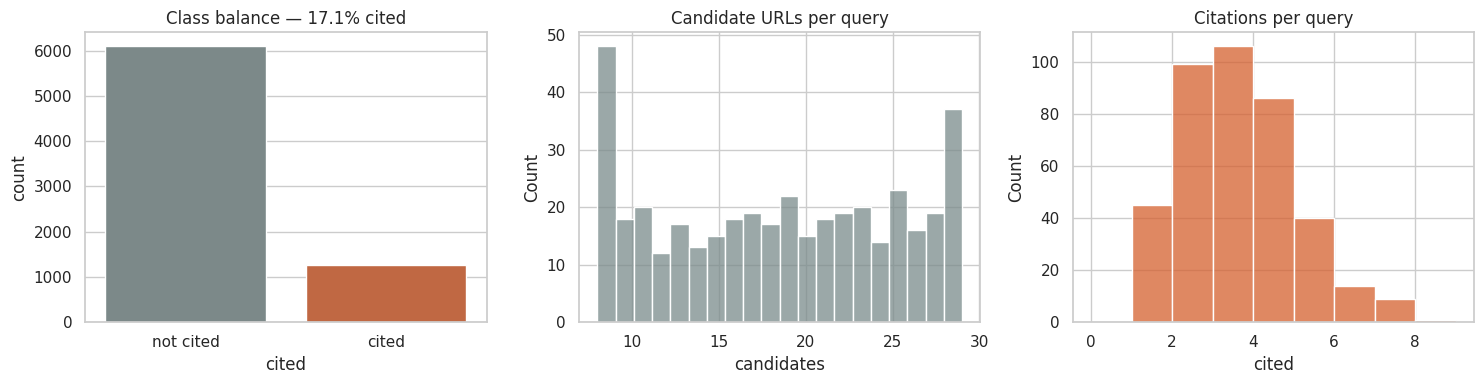

       candidates   cited
count      400.00  400.00
mean        18.40    3.15
std          6.52    1.43
min          8.00    1.00
25%         13.00    2.00
50%         19.00    3.00
75%         24.00    4.00
max         29.00    8.00


In [4]:
per_query = df.groupby(config.GROUP_COL).agg(
    candidates=("url", "size"), cited=(config.TARGET, "sum"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x=df[config.TARGET], palette=["#7a8b8b", "#d5602e"], ax=axes[0])
axes[0].set_title(f"Class balance — {df[config.TARGET].mean():.1%} cited")
axes[0].set_xticklabels(["not cited", "cited"])
sns.histplot(per_query["candidates"], bins=20, color="#7a8b8b", ax=axes[1])
axes[1].set_title("Candidate URLs per query")
sns.histplot(per_query["cited"], bins=range(0, 10), color="#d5602e", ax=axes[2])
axes[2].set_title("Citations per query")
plt.tight_layout(); plt.show()
print(per_query.describe().round(2))

### 3.2 Feature correlation (seaborn heatmap)

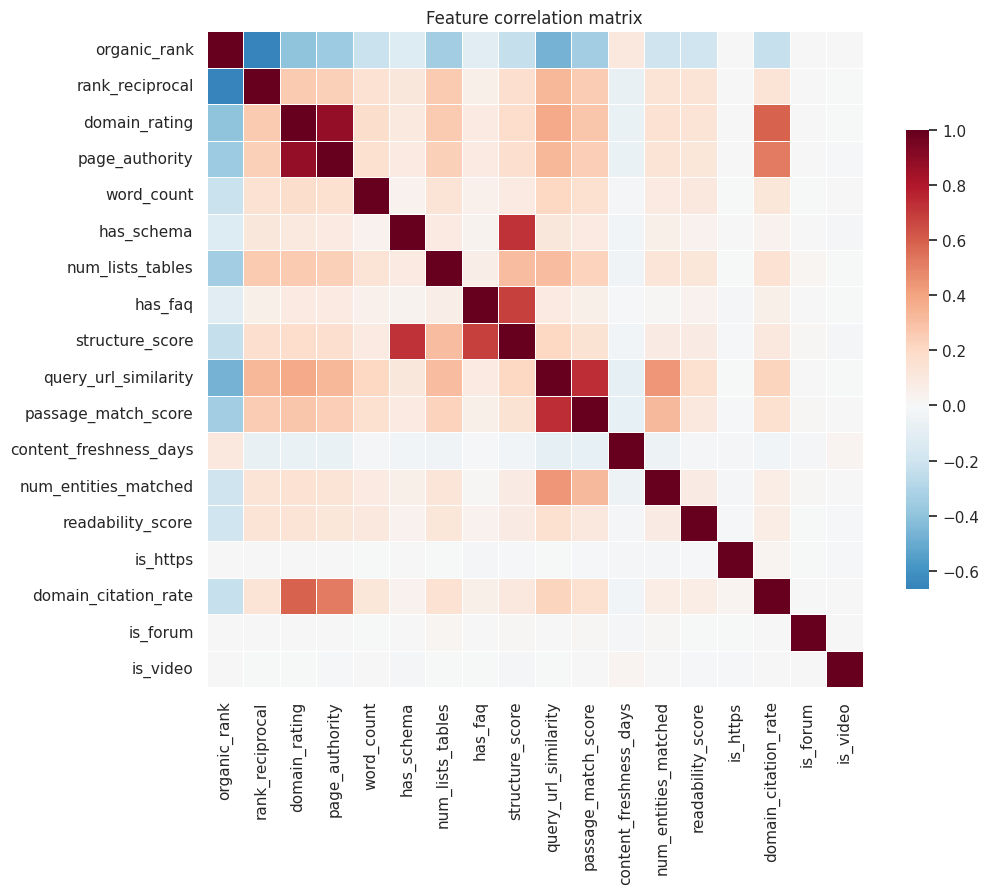

In [5]:
st.plot_correlation_heatmap(df); plt.show()

### 3.3 How signals differ between cited and non-cited URLs

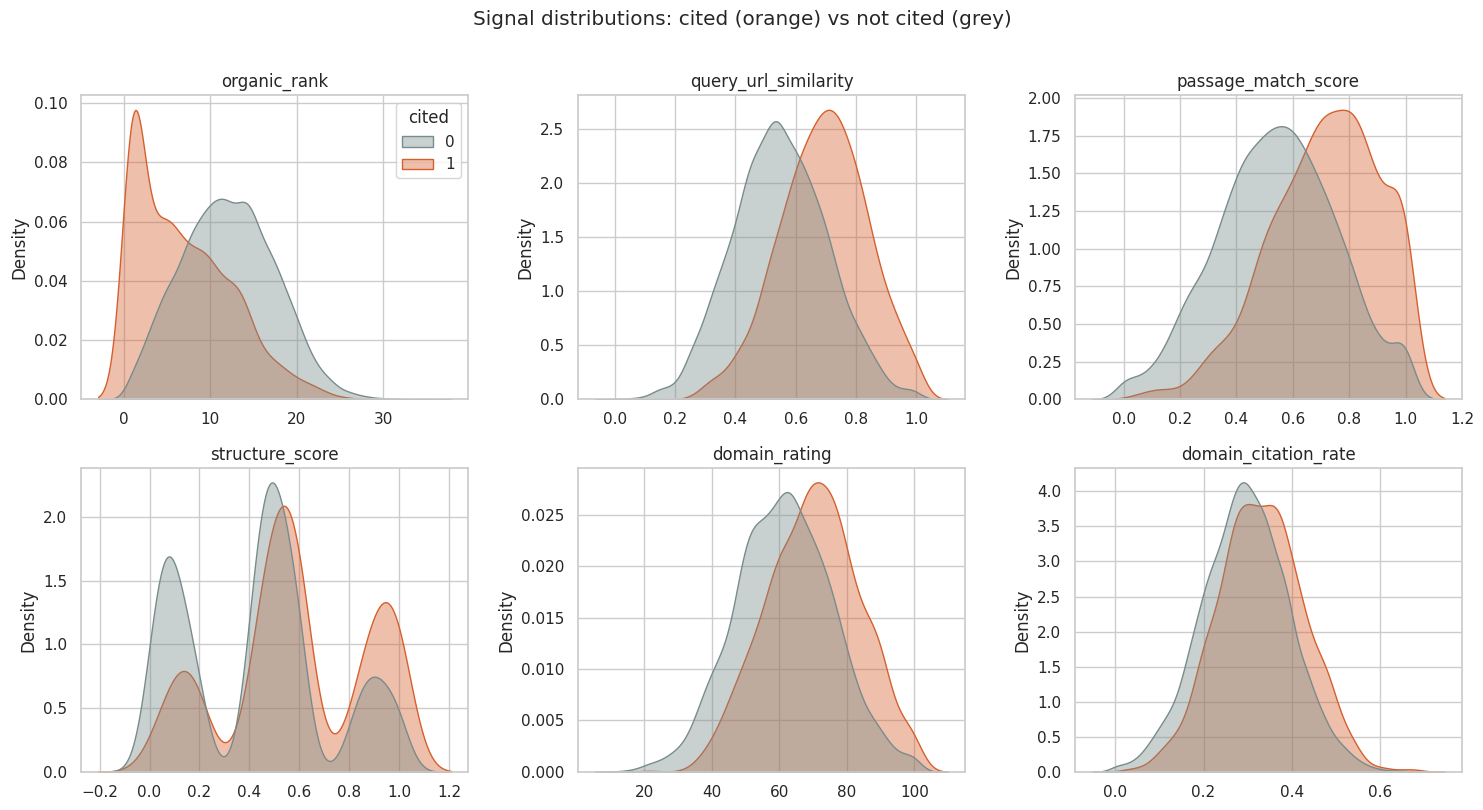

In [6]:
st.plot_signal_distributions(df); plt.show()

## 4 — Inferential statistics: do the groups really differ?

The A/B-testing mindset on observational data: treat *cited* vs *not cited* as
two groups and test where they diverge. Features are skewed and non-normal, so
we use the **Mann-Whitney U** test (not a t-test) and report a rank-biserial
**effect size** so significance on ~7k rows isn't mistaken for a large effect.

In [7]:
tests = st.hypothesis_tests(df)
tests.round({"median_cited": 3, "median_not_cited": 3,
             "u_statistic": 0, "p_value": 6, "effect_size_r": 3})

,feature,median_cited,median_not_cited,u_statistic,p_value,effect_size_r
0,organic_rank,6.000,12.000,1869285.0,0.0,0.514
1,query_url_similarity,0.696,0.544,5786874.0,0.0,-0.506
2,passage_match_score,0.732,0.545,5597836.0,0.0,-0.456
3,domain_rating,70.400,61.400,5140274.0,0.0,-0.337
4,structure_score,0.560,0.480,5112760.0,0.0,-0.330
5,num_entities_matched,9.000,8.000,4848579.0,0.0,-0.261
6,domain_citation_rate,0.328,0.295,4613144.0,0.0,-0.200
7,word_count,1742.500,1575.000,4360559.0,0.0,-0.134


Descriptive summary by class (mean / median / std):

In [8]:
st.descriptive_by_class(df)

cited                        0                            1                   
                          mean    median      std      mean    median      std
organic_rank            12.099    12.000    5.321     6.887     6.000    5.448
query_url_similarity     0.548     0.544    0.155     0.692     0.696    0.144
passage_match_score      0.543     0.545    0.212     0.715     0.732    0.193
structure_score          0.427     0.480    0.289     0.585     0.560    0.285
domain_rating           61.394    61.400   14.387    70.073    70.400   13.674
domain_citation_rate     0.295     0.295    0.099     0.330     0.328    0.097
num_entities_matched     7.924     8.000    3.129     9.479     9.000    3.342
word_count            1580.810  1575.000  614.763  1730.555  1742.500  639.394

## 5 — Feature engineering
`build_xy` adds `rank_reciprocal` (1/rank, the non-linear visibility decay) and `structure_score` (a single 'how extractable is this page' signal) and casts categoricals to pandas `category` dtype for LightGBM.

In [9]:
X, y, groups = build_xy(df)
print("X shape:", X.shape, "| any NaNs:", bool(X.isna().any().any()))
print("categoricals:", [c for c in X.columns if str(X[c].dtype) == 'category'])
X.head(3)

X shape: (7361, 19) | any NaNs: False
categoricals: ['content_type']


,organic_rank,rank_reciprocal,domain_rating,page_authority,word_count,has_schema,num_lists_tables,has_faq,structure_score,query_url_similarity,passage_match_score,content_freshness_days,num_entities_matched,readability_score,is_https,domain_citation_rate,is_forum,is_video,content_type
0,15,0.066667,40.7,47.7,1271,0,2,0,0.08,0.508,0.582,164,5,60.1,1,0.184,0,0,informational
1,15,0.066667,43.9,45.7,1144,1,1,0,0.44,0.555,0.576,158,8,60.4,1,0.195,0,0,transactional
2,22,0.045455,60.1,65.6,1317,1,1,0,0.44,0.400,0.503,161,10,44.7,1,0.195,0,0,informational


## 6 — Leakage-safe cross-validation: two models

`GroupKFold(groups=query_id)` keeps every query wholly inside one fold. We train
a transparent **logistic regression** (scaled numerics + one-hot categoricals)
and a **LightGBM** tree model on the *same* folds, and collect out-of-fold
predictions for both.

In [10]:
cv = run_group_kfold_cv(X, y, groups, verbose=True)
oof_lr = run_logreg_group_kfold_cv(X, y, groups)
print(f"\nLightGBM per-fold PR-AUC: {cv.mean_ap:.4f} +/- {cv.std_ap:.4f}")

  fold 1/5  PR-AUC = 0.5926  (best_iter=93)


  fold 2/5  PR-AUC = 0.5793  (best_iter=75)
  fold 3/5  PR-AUC = 0.5521  (best_iter=60)


  fold 4/5  PR-AUC = 0.5868  (best_iter=36)
  fold 5/5  PR-AUC = 0.5511  (best_iter=37)



LightGBM per-fold PR-AUC: 0.5724 +/- 0.0175


## 7 — Evaluation vs baselines

Scored per-fold on the shared GroupKFold splits (mean ± std), so the comparison
is apples-to-apples. The bar to beat is the **rank-only heuristic** (predict
citation from organic position alone).

In [11]:
comparison = ev.compare_models(df, {
    "Gap-Miner (LightGBM)": cv.oof_pred,
    "Logistic Regression": oof_lr,
}, groups)
comparison

,pr_auc,pr_auc_std,roc_auc,precision_at_k
model,,,,
Gap-Miner (LightGBM),0.5724,0.0175,0.8150,0.5909
Logistic Regression,0.5853,0.0150,0.8278,0.6115
Rank-only heuristic,0.4825,0.0085,0.7572,0.5260
Random / prevalence,0.1712,0.0000,0.5000,NaN


**Read-out.** Both learned models beat the rank-only heuristic by ~10 PR-AUC points and lift per-query precision@k. On this synthetic data the label is close to linear in the engineered features, so logistic regression is very competitive; gradient boosting's edge typically grows with the non-linear interactions present in real citation data. LightGBM is carried forward for SHAP because tree attributions are exact.

### 7.1 Precision-Recall curve

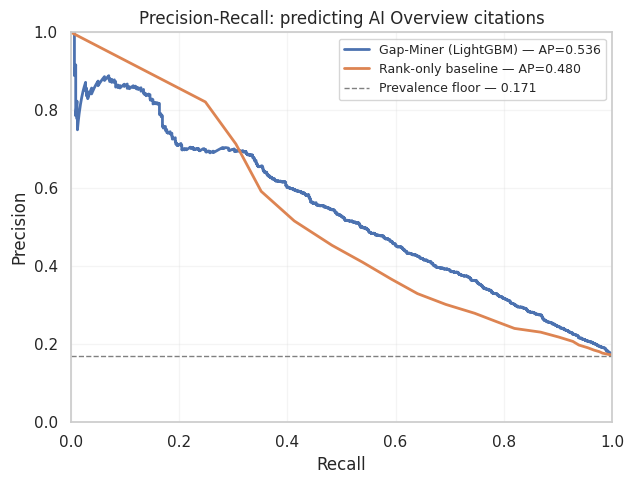

In [12]:
ev.plot_pr_curves(df, cv.oof_pred); plt.show()

### 7.2 Confusion matrix at the F1-optimal threshold

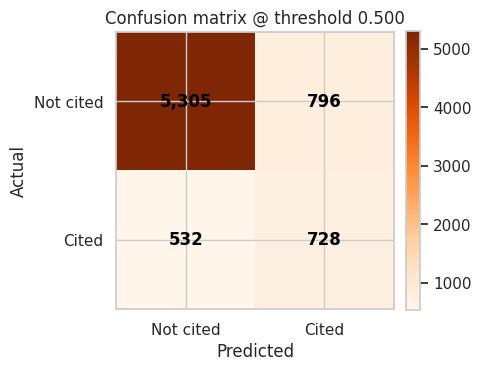

Operating threshold: 0.500 | F1 = 0.523


In [13]:
summary = ev.evaluation_summary(df, cv.oof_pred)
ev.plot_confusion(df, cv.oof_pred, threshold=summary["best_f1_threshold"]); plt.show()
print(f"Operating threshold: {summary['best_f1_threshold']:.3f} | F1 = {summary['best_f1']:.3f}")

## 8 — Explainability (TreeSHAP)
Why does a URL get cited? Train a final LightGBM on all rows (at the mean best CV iteration) and attribute predictions with TreeSHAP.

In [14]:
final_model = train_final_model(X, y, n_estimators=int(np.mean(cv.best_iterations)))
explainer, shap_values = ex.compute_shap_values(final_model, X)
importance = ex.mean_abs_importance(shap_values, list(X.columns))
importance.head(10)

,feature,mean_abs_shap
0,query_url_similarity,0.335827
1,organic_rank,0.279193
2,passage_match_score,0.224022
3,structure_score,0.151208
4,rank_reciprocal,0.075823
5,domain_rating,0.068462
6,content_freshness_days,0.058927
7,num_entities_matched,0.057331
8,is_forum,0.047126
9,page_authority,0.043819


### 8.1 Global importance and direction (beeswarm)

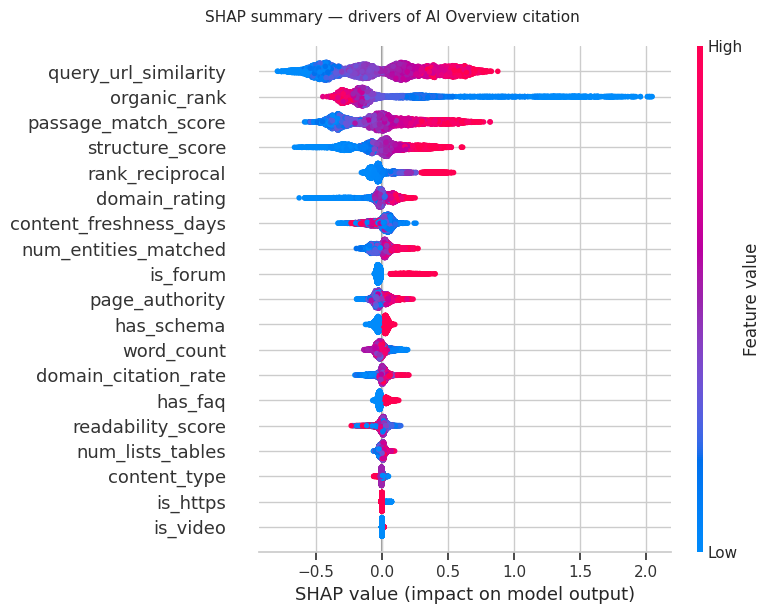

In [15]:
ex.plot_beeswarm(shap_values, X); plt.show()

### 8.2 Response curve for the top driver

<Figure size 650x500 with 0 Axes>

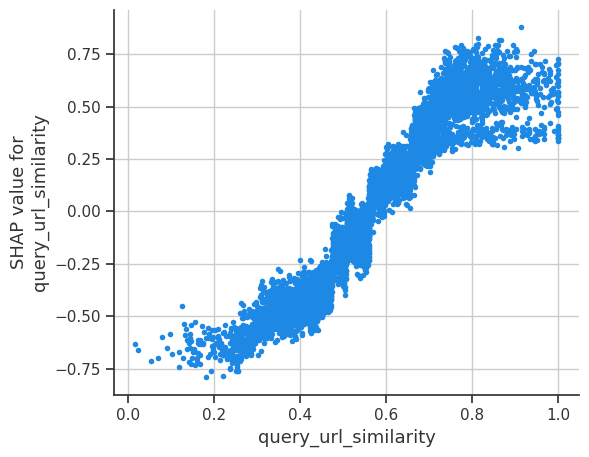

Top driver: query_url_similarity


In [16]:
top_feature = importance.iloc[0]["feature"]
ex.plot_dependence(shap_values, X, top_feature); plt.show()
print("Top driver:", top_feature)

## 9 — Read-out, Tableau hand-off & next steps

**What the method shows (synthetic data).** Both models beat a strong rank-only
heuristic on PR-AUC and per-query precision@k, and SHAP attributes the edge to
**semantic passage match, content structure, and domain citation history** —
signals raw ranking position can't see. That is the GEO thesis made measurable:
*structured, on-topic pages get cited beyond what their SERP position predicts.*

**Tableau hand-off.** `python scripts/export_tableau.py` writes a flat, scored
extract (`tableau/aio_gap_miner_tableau.csv`) with both models' probabilities, a
**citation-gap flag** (predicted-cited but not yet cited = the opportunity), and
the strongest SHAP driver per row. The interactive dashboard is built on that
(see `tableau/README.md`).

**From here:**
1. **Real labels** — swap the synthetic sample for labelled AI Overview citation
   data (same schema). No pipeline changes.
2. **Richer features** — real embeddings for query↔passage similarity, NER entity
   coverage, SERP-feature flags, Core Web Vitals.
3. **Calibration** — isotonic/Platt on top of the ranker for an absolute
   "citation likelihood" score.
4. **Gap reports** — per-page SHAP names the specific levers (add FAQ schema,
   tighten the answer passage, raise topical coverage) to close a citation gap —
   the analytical layer a rules-based tool can't offer.